# 리뷰 데이터 EDA
> 전처리 품질 검증 + 주요 인사이트 탐색

**목차**
1. 환경 설정 & 데이터 로드
2. 기본 품질 체크
3. 감성 레이블 신뢰성 확인
4. 토픽 분류 품질 확인
5. 조인 품질 확인
6. 시각화
7. 요약 리포트

---
## 0. 환경 설정 & 데이터 로드

In [23]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from matplotlib.patches import Patch
from IPython.display import display
import pymysql
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print("라이브러리 로드 완료")

# ── 색상 팔레트 ─────────────────────────────────
COLORS = {
    'positive': '#4C9B82',
    'negative': '#E06C6C',
    'neutral':  '#A0A0A0',
    'base':     '#3A7BD5',
    'warn':     '#E8A838',
}

print('✅ 환경 설정 완료')

라이브러리 로드 완료
✅ 환경 설정 완료


In [24]:
# ▶ 경로를 실제 파일 위치로 수정하세요
FILE_PATH = 'tableau_reviews.csv'   # ← 여기 수정

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
df['작성일'] = pd.to_datetime(df['작성일'], errors='coerce')

print(f'shape  : {df.shape}')
print(f'컬럼   : {df.columns.tolist()}')
df.head(3)

shape  : (626132, 35)
컬럼   : ['리뷰번호', 'goodsNo', '리뷰타입', '평점', '작성일', '리뷰내용_clean', 'topic_id', 'p_pos', 'p_neg', 'p_neu', 'sentiment', '성별', '구매사이즈', '구매상세', '사진유무', '도움돼요', '체험단', '만족도_응답여부', '퀄리티_점수', '보온성_점수', '신축성_점수', '두께감_점수', '구김_점수', '연도', '월', '연월', '브랜드', '카테고리', '상품명', '판매가', '누적판매수', 'topic_keyword', 'topic_category', 'topic_name', '리뷰내용']


,리뷰번호,goodsNo,리뷰타입,평점,작성일,리뷰내용_clean,topic_id,p_pos,p_neg,p_neu,...,연월,브랜드,카테고리,상품명,판매가,누적판매수,topic_keyword,topic_category,topic_name,리뷰내용
0,34612047,1733275,goods,5.0,2022-11-07 18:13:53,요즘 입기 좋은 것 같아요 무난무난하게 잘 입고있습니다,67.0,0.972076,0.007824,0.020101,...,2022-11,제멋,상의,로그 오버핏 기모 후드 다크그레이 YHHD2302,37900.0,15443.0,코디,착용/스타일,무난한 코디,요즘 입기 좋은 것 같아요 무난무난하게 잘 입고있습니다
1,51564285,3070563,goods,5.0,2023-11-23 15:50:39,잠옷용으로 구매했어요 편하고 그냥 입기에도 조아요,16.0,0.957553,0.011755,0.030692,...,2023-11,제멋,상의,크로우 오버핏 긴팔티셔츠 5종 블랙 KJLT2459,10800.0,121.0,동네,착용/스타일,동네/잠옷,잠옷용으로 구매했어요 편하고 그냥 입기에도 조아요
2,46679669,3251750,goods,5.0,2023-08-01 15:28:26,잠옷용으로 휘뚜루마뚜루 입으려고 좀 크게 사긴했는데 진짜 많이 커요 조금은 두꺼운 ...,16.0,0.009052,0.960236,0.030712,...,2023-08,제멋,상의,브라이트 오버핏 반팔티셔츠 11종 블랙 KJST2490,15900.0,114.0,동네,착용/스타일,동네/잠옷,잠옷용으로 휘뚜루마뚜루 입으려고 좀 크게 사긴했는데 진짜 많이 커요 조금은 두꺼운 ...


---
## 1. 기본 품질 체크

In [25]:
# ── 1-1. 결측치 현황 ────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측률(%)', ascending=False)

print('[1-1] 결측치 현황')
display(missing_df)

[1-1] 결측치 현황


,결측수,결측률(%)
보온성_점수,624575,99.75
구김_점수,624573,99.75
신축성_점수,617709,98.65
두께감_점수,614340,98.12
퀄리티_점수,608744,97.22
구매상세,229141,36.60
topic_id,25079,4.01
리뷰내용,25079,4.01
평점,1628,0.26
구매사이즈,552,0.09


In [26]:
# ── 1-2. 중복 리뷰번호 ──────────────────────────
dup_cnt = df['리뷰번호'].duplicated().sum()
print(f'[1-2] 중복 리뷰번호: {dup_cnt:,}건')

if dup_cnt > 0:
    display(df[df['리뷰번호'].duplicated(keep=False)]
            [['리뷰번호', '작성일', '리뷰내용_clean']].head(10))

[1-2] 중복 리뷰번호: 419건


,리뷰번호,작성일,리뷰내용_clean
625195,83747215,2026-04-17 11:30:13,기모인줄 모르고 샀으나 가격대비 옷이 예뻐서 입습니다 까만색 털이 묻어나오는건 조금 아쉽
625196,83465495,2026-04-05 18:24:30,좋아요 다음에 또 구매할께요 저렴하게 구매해서 좋ㅎ네요.
625197,83648573,2026-04-13 15:33:10,핏두요즘트랜드에 맞고배송이일단빠르네요 전체적으로괜찮네요
625198,83650001,2026-04-13 16:38:21,데님브랜드1위찍은 이유가있네요 가볍고핏두오져요
625199,83828396,2026-04-20 16:47:56,생각했던 색감이라 좋아요 팔 통이 커서 핏이 어색하긴 하지만 m사이즈 샀으면 더 어...
625200,83783269,2026-04-18 20:35:45,"기본 후드티로 초봄, 가을 겨울에 입으면 따뜻해요. 꾸안꾸 느낌내기 좋습니다."
625201,83914664,2026-04-23 20:50:06,여름용으로 두께가 얇아서 딱 좋은것 같아요 기장은 살짝 길어서 건조기돌려보고 그래도...
625202,83914679,2026-04-23 20:51:11,밴딩이라 편하게 입을수 있어서 좋아요 핏도 생각했던대로 이뻐요
625203,83380310,2026-04-01 23:40:13,크롭이너티를 찾고 있었는데 딱 맞는걸 찾았어요 팔부분이 살짝 길게 느껴질수도 있는데...
625204,83390398,2026-04-02 13:42:22,약간 크롭한 이너티를 찾고 있었는데 딱 맞는티를 찾았어요 다만 팔소매길이가 좀 짧았...


In [27]:
# 중복이면 어떤 컬럼이 다른지 확인
dup_rows = df[df['리뷰번호'].duplicated(keep=False)].sort_values('리뷰번호')
display(dup_rows[['리뷰번호', 'goodsNo', '작성일', '브랜드', '리뷰내용_clean']].head(20))

,리뷰번호,goodsNo,작성일,브랜드,리뷰내용_clean
626122,80333990,3516242,2026-04-17 02:45:51,제멋,엉덩이를 완전히 덮는 박시핏이에요. 두께감은 간절기용으로 입기 좋습니다. 후드 크기...
625606,80333990,3516242,2026-04-17 02:45:51,제멋,엉덩이를 완전히 덮는 박시핏이에요. 두께감은 간절기용으로 입기 좋습니다. 후드 크기...
625874,81964951,3963796,2026-04-06 23:46:03,트래블,처음 입어보는 브랜드인데 쫀쫀하고 좋은 것 같습니다
625401,81964951,3963796,2026-04-06 23:46:03,트래블,처음 입어보는 브랜드인데 쫀쫀하고 좋은 것 같습니다
625378,83273691,2913656,2026-04-20 00:34:31,필루미네이트,낙낙하지만 넘이뻐요 잘받았습니다 천도 짱짱 상품좋아요 좋은 상품 계속 부탁드립니다
625847,83273691,2913656,2026-04-20 00:34:31,필루미네이트,낙낙하지만 넘이뻐요 잘받았습니다 천도 짱짱 상품좋아요 좋은 상품 계속 부탁드립니다
625940,83348377,6071165,2026-04-02 16:31:46,제멋,"색감이 크림보단 살짝 라이트베이지 느낌이 좀 있지만, 바지도 가볍고 이쁘고 가볍게 ..."
625454,83348377,6071165,2026-04-02 16:31:46,제멋,"색감이 크림보단 살짝 라이트베이지 느낌이 좀 있지만, 바지도 가볍고 이쁘고 가볍게 ..."
626110,83353946,4728654,2026-04-01 01:03:34,필루미네이트,적당히 입고다니기 좋아요 잘 입고 다니고있어요
625594,83353946,4728654,2026-04-01 01:03:34,필루미네이트,적당히 입고다니기 좋아요 잘 입고 다니고있어요


In [28]:
# ── 1-3. 작성일 범위 ────────────────────────────
nat_cnt = df['작성일'].isna().sum()
print(f'[1-3] 작성일 범위')
print(f'  최초 : {df["작성일"].min()}')
print(f'  최근 : {df["작성일"].max()}')
print(f'  파싱 실패(NaT) : {nat_cnt}건')

[1-3] 작성일 범위
  최초 : 2015-08-13 17:31:14
  최근 : 2026-04-29 23:21:58
  파싱 실패(NaT) : 0건


In [29]:
# ── 1-4. 평점 분포 ──────────────────────────────
print('[1-4] 평점 분포')
display(df['평점'].value_counts().sort_index().rename('리뷰수').to_frame())

invalid_rating = df[~df['평점'].isin([1.0, 2.0, 3.0, 4.0, 5.0])]['평점'].unique()
print(f'이상 평점값: {invalid_rating}')

[1-4] 평점 분포


,리뷰수
평점,
1.0,1674
2.0,2137
3.0,16743
4.0,88831
5.0,515119


이상 평점값: [nan]


---
## 2. 감성 레이블 신뢰성 확인

In [30]:
# ── 2-1. 감성 분포 ──────────────────────────────
sent_cnt = df['sentiment'].value_counts()
sent_pct = df['sentiment'].value_counts(normalize=True).mul(100).round(2)
print('[2-1] sentiment 분포')
display(pd.DataFrame({'건수': sent_cnt, '비율(%)': sent_pct}))

[2-1] sentiment 분포


,건수,비율(%)
sentiment,,
positive,504700,80.61
negative,63906,10.21
neutral,57526,9.19


In [31]:
# ── 2-2. 평점 × 감성 교차표 ─────────────────────
print('[2-2] 평점 × sentiment 교차표')
cross = pd.crosstab(df['평점'], df['sentiment'], margins=True)
display(cross)

[2-2] 평점 × sentiment 교차표


sentiment,negative,neutral,positive,All
평점,,,,
1.0,1515,65,94,1674
2.0,1838,167,132,2137
3.0,9273,2448,5022,16743
4.0,20869,13894,54068,88831
5.0,30322,40665,444132,515119
All,63817,57239,503448,624504


In [32]:
# ── 2-3. 모순 케이스 ────────────────────────────
high_neg = df[(df['평점'] >= 4) & (df['sentiment'] == 'negative')]
low_pos  = df[(df['평점'] <= 2) & (df['sentiment'] == 'positive')]

print(f'[2-3] 모순 케이스')
print(f'  평점 4~5 & negative : {len(high_neg):,}건  ({len(high_neg)/len(df)*100:.1f}%)')
print(f'  평점 1~2 & positive : {len(low_pos):,}건   ({len(low_pos)/len(df)*100:.1f}%)')

print('\n▶ 평점 5 & negative 샘플 5건')
display(df[(df['평점'] == 5) & (df['sentiment'] == 'negative')]
        [['리뷰번호', '리뷰내용_clean', 'p_neg']].head(5))

[2-3] 모순 케이스
  평점 4~5 & negative : 51,191건  (8.2%)
  평점 1~2 & positive : 226건   (0.0%)

▶ 평점 5 & negative 샘플 5건


,리뷰번호,리뷰내용_clean,p_neg
2,46679669,잠옷용으로 휘뚜루마뚜루 입으려고 좀 크게 사긴했는데 진짜 많이 커요 조금은 두꺼운 ...,0.960236
3,49013088,잠옷으로 입으려고 크게 사긴했는데 정말 크고 두꺼워요,0.979170
14,42693190,옷감이 가벼워 여름에 시원하게 입을수 있겠네요뒷주머니가 사진에 안보였는데 진짜로 없...,0.976947
42,4625422,처음 M 주문했는데 너무 타이트해서 XL 했더니 너무 크네요 옷 자체는 재질도 스타...,0.781265
63,45234684,배송 두 달 걸렸어요 비싼 제품도 아니라 이렇게까지 기다려야 하나 싶었지만 그냥 오...,0.581327


In [33]:
# ── 2-4. 확률 합 검증 ───────────────────────────
prob_sum = df['p_pos'] + df['p_neg'] + df['p_neu']
weird = df[np.abs(prob_sum - 1) > 0.01]

print('[2-4] p_pos + p_neg + p_neu 합 검증')
print(f'  min  : {prob_sum.min():.6f}')
print(f'  max  : {prob_sum.max():.6f}')
print(f'  mean : {prob_sum.mean():.6f}')
print(f'  합이 1±0.01 벗어난 행: {len(weird)}건')

[2-4] p_pos + p_neg + p_neu 합 검증
  min  : 1.000000
  max  : 1.000000
  mean : 1.000000
  합이 1±0.01 벗어난 행: 0건


In [34]:
# ── 2-5. 감성 신뢰도 분포 ───────────────────────
max_prob = df[['p_pos', 'p_neg', 'p_neu']].max(axis=1)
bins   = [0, 0.5, 0.7, 0.9, 0.95, 1.0]
labels = ['~0.5', '0.5~0.7', '0.7~0.9', '0.9~0.95', '0.95~1.0']
prob_dist = pd.cut(max_prob, bins=bins, labels=labels).value_counts().sort_index()

print('[2-5] 최대 확률값 분포 (신뢰도)')
display(prob_dist.rename('리뷰수').to_frame())
print(f'\n0.7 미만 애매한 케이스: {(max_prob < 0.7).sum():,}건 ({(max_prob < 0.7).mean()*100:.1f}%)')

[2-5] 최대 확률값 분포 (신뢰도)


,리뷰수
~0.5,20835
0.5~0.7,56042
0.7~0.9,95303
0.9~0.95,93228
0.95~1.0,360724



0.7 미만 애매한 케이스: 76,877건 (12.3%)


---
## 3. 토픽 분류 품질 확인

In [35]:
# ── 3-1. 아웃라이어 비율 ────────────────────────
outlier = df[df['topic_id'] == -1]
print(f'[3-1] 아웃라이어(topic_id == -1)')
print(f'  {len(outlier):,}건 / 전체 {len(df):,}건 ({len(outlier)/len(df)*100:.1f}%)')

[3-1] 아웃라이어(topic_id == -1)
  189,329건 / 전체 626,132건 (30.2%)


In [36]:
# ── 3-2. topic_category / topic_name 결측 ──────
print('[3-2] topic_category / topic_name 결측')
print(f'  topic_category 결측 : {df["topic_category"].isna().sum()}건')
print(f'  topic_name     결측 : {df["topic_name"].isna().sum()}건')

[3-2] topic_category / topic_name 결측
  topic_category 결측 : 0건
  topic_name     결측 : 0건


In [37]:
# ── 3-3. 토픽별 리뷰 수 (상위 20) ──────────────
print('[3-3] topic_name 별 리뷰 수 (Top 20)')
display(df['topic_name'].value_counts().head(20).rename('리뷰수').to_frame())

[3-3] topic_name 별 리뷰 수 (Top 20)


,리뷰수
topic_name,
아웃라이어,214408
바지/팬츠,30428
배송 속도,28526
후드티,19288
워싱/화면 색감,18948
기모,18707
L/M/S 사이즈,15660
세탁/건조기/변형,14530
기본 컬러,14446


In [38]:
# ── 3-4. 토픽 대분류별 리뷰 수 ─────────────────
print('[3-4] topic_category 별 리뷰 수')
display(df['topic_category'].value_counts().rename('리뷰수').to_frame())

[3-4] topic_category 별 리뷰 수


,리뷰수
topic_category,
아웃라이어,214408
사이즈/핏,78449
상품 카테고리,72125
색상/사진,44986
소재/두께감,39023
시즌/날씨,36806
착용/스타일,29245
배송,28526
가격/가성비,27740


---
## 4. 조인 품질 확인

In [39]:
# ── 4-1. 상품 정보 결측 ─────────────────────────
print('[4-1] 상품 정보 결측')
for col in ['브랜드', '카테고리', '상품명', '판매가', '누적판매수']:
    cnt = df[col].isna().sum()
    print(f'  {col} : {cnt:,}건 ({cnt/len(df)*100:.1f}%)')

[4-1] 상품 정보 결측
  브랜드 : 2건 (0.0%)
  카테고리 : 2건 (0.0%)
  상품명 : 2건 (0.0%)
  판매가 : 2건 (0.0%)
  누적판매수 : 2건 (0.0%)


In [40]:
# ── 4-2. 판매가 / 누적판매수 기초 통계 ──────────
print('[4-2] 판매가 / 누적판매수 기초 통계')
display(df[['판매가', '누적판매수']].describe().round(1))
print(f'\n판매가 0 이하  : {(df["판매가"] <= 0).sum()}건')
print(f'누적판매수 0   : {(df["누적판매수"] == 0).sum()}건')

[4-2] 판매가 / 누적판매수 기초 통계


,판매가,누적판매수
count,626130.0,626130.0
mean,39275.5,42760.3
std,15103.5,44451.5
min,7900.0,0.0
25%,29900.0,5842.0
50%,37900.0,26582.0
75%,45000.0,66872.0
max,169000.0,149876.0



판매가 0 이하  : 0건
누적판매수 0   : 3739건


In [41]:
# ── 4-3. 리뷰내용 vs 리뷰내용_clean 길이 비교 ───
if '리뷰내용' in df.columns:
    df['len_orig']  = df['리뷰내용'].str.len().fillna(0)
    df['len_clean'] = df['리뷰내용_clean'].str.len().fillna(0)
    df['len_diff']  = df['len_orig'] - df['len_clean']
    print('[4-3] 리뷰내용 vs 리뷰내용_clean 길이 비교')
    display(df[['len_orig', 'len_clean', 'len_diff']].describe().round(1))
    print('\n길이 차이 50자 이상 샘플 5건')
    display(df[df['len_diff'] > 50][['리뷰번호', '리뷰내용', '리뷰내용_clean', 'len_diff']].head(5))
else:
    print('리뷰내용 컬럼 없음 — 건너뜀')

[4-3] 리뷰내용 vs 리뷰내용_clean 길이 비교


,len_orig,len_clean,len_diff
count,626132.0,626132.0,626132.0
mean,42.9,44.3,-1.5
std,31.0,29.7,9.3
min,0.0,5.0,-656.0
25%,29.0,29.0,0.0
50%,35.0,35.0,0.0
75%,48.0,48.0,0.0
max,1460.0,1415.0,216.0



길이 차이 50자 이상 샘플 5건


,리뷰번호,리뷰내용,리뷰내용_clean,len_diff
4519,32346017,와&hellip; 말도 마세요&hellip; 역시 제멋. 사실 제멋에서 옷 처음 사...,와 말도 마세요 역시 제멋. 사실 제멋에서 옷 처음 사봤지만 사자마자 성공. 너무 ...,60.0
6514,35476897,싸게사서 이쁘게 잘 입고있어요❤️&zwj;🔥❤️&zwj;🔥❤️&zwj;🔥❤️&zwj...,싸게사서 이쁘게 잘 입고있어요,56.0
9398,468787,베이지색 구매했어요 색상은 화면이랑 거의 같네요<br /> <br /> 사이즈때문에...,베이지색 구매했어요 색상은 화면이랑 거의 같네요 사이즈때문에 고민했는데 XL로 가면...,52.0
70292,8381062,"평소에 아우터를 입을 때, 어느정도 여유로운 걸 선호한다. ...","평소에 아우터를 입을 때, 어느정도 여유로운 걸 선호한다. = 한사이즈 업 딱 맞게...",117.0
70403,1010657,ㅎ기모에 루즈핏이여서 사봣는데..굳초이스<br /> 이건 깔별로 쟁겨놔도 조을거같...,ㅎ기모에 루즈핏이여서 사봣는데..굳초이스 이건 깔별로 쟁겨놔도 조을거같음 블랙이랑 ...,123.0


---
## 5. 시각화

In [42]:
# 시각화에 필요한 파생 컬럼 사전 준비
df['리뷰길이'] = df['리뷰내용_clean'].str.len()
max_prob = df[['p_pos', 'p_neg', 'p_neu']].max(axis=1)

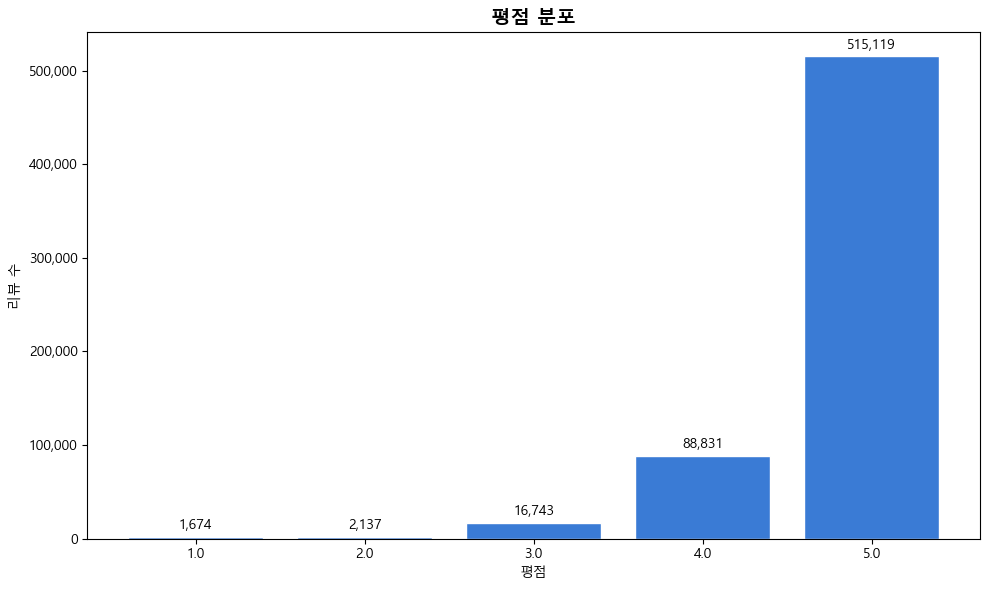

In [58]:
# ── 5-1. 평점 분포 ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
rating_cnt = df['평점'].value_counts().sort_index()
bars = ax.bar(rating_cnt.index.astype(str), rating_cnt.values,
              color=COLORS['base'], edgecolor='white')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + rating_cnt.max()*0.01,
            f'{b.get_height():,}', ha='center', va='bottom', fontsize=10)
ax.set_title('평점 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('평점')
ax.set_ylabel('리뷰 수')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

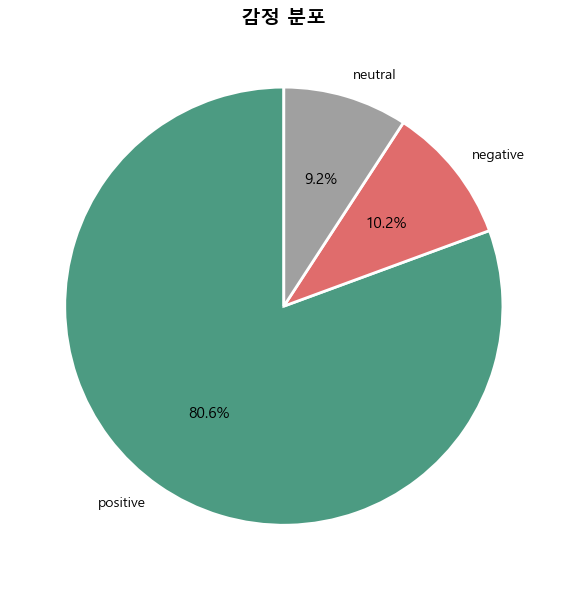

In [59]:
# ── 5-2. 감성 분포 ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
sent_cnt = df['sentiment'].value_counts()
colors_pie = [COLORS.get(s, '#ccc') for s in sent_cnt.index]
wedges, texts, autotexts = ax.pie(
    sent_cnt.values, labels=sent_cnt.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('감정 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

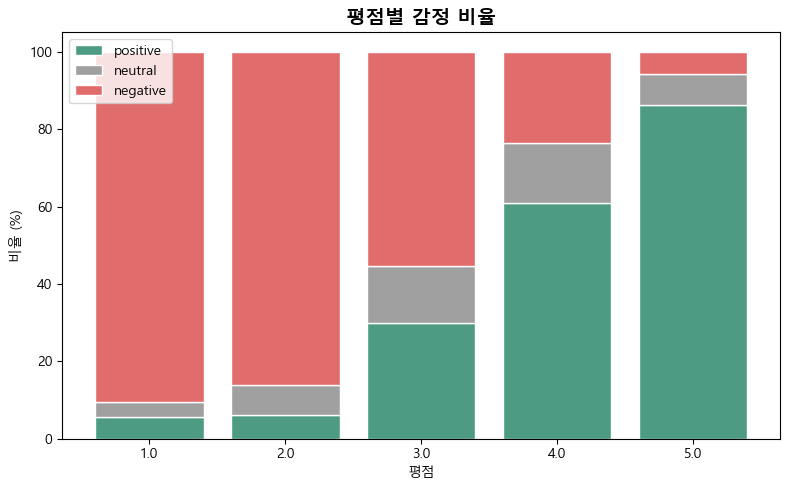

In [60]:
# ── 5-3. 평점별 감성 비율 (stacked bar) ─────────
fig, ax = plt.subplots(figsize=(8, 5))
cross_pct = pd.crosstab(df['평점'], df['sentiment'], normalize='index') * 100
cross_pct = cross_pct.reindex(columns=['positive', 'neutral', 'negative'])
bottom = np.zeros(len(cross_pct))
for col in cross_pct.columns:
    ax.bar(cross_pct.index.astype(str), cross_pct[col],
           bottom=bottom, label=col, color=COLORS.get(col, '#ccc'), edgecolor='white')
    bottom += cross_pct[col].values
ax.set_title('평점별 감정 비율', fontsize=14, fontweight='bold')
ax.set_xlabel('평점')
ax.set_ylabel('비율 (%)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

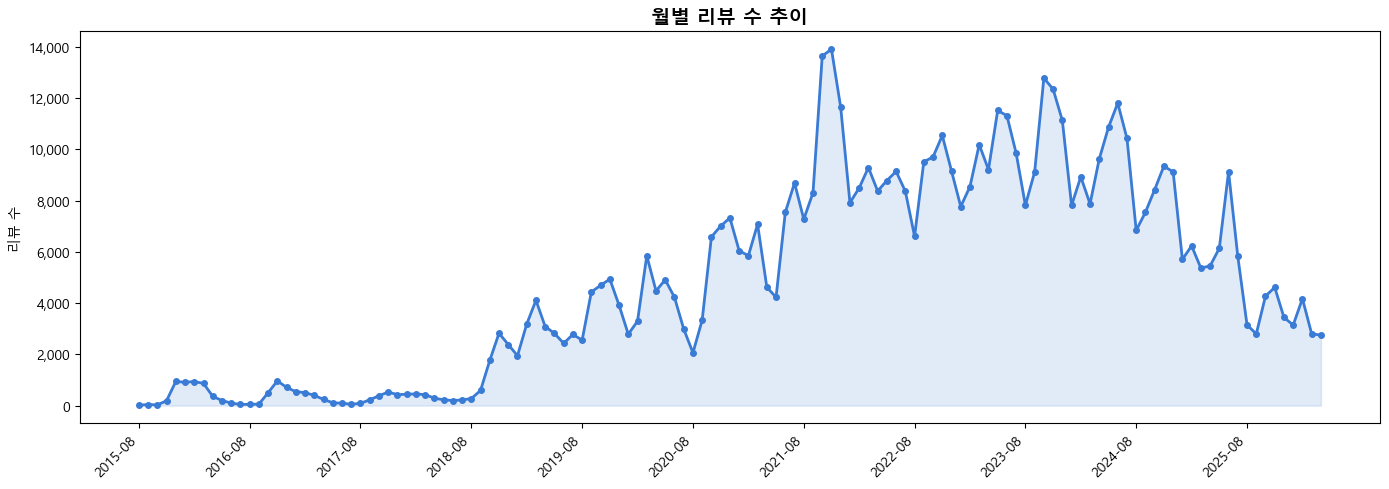

In [46]:
# ── 5-4. 월별 리뷰 수 추이 ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
monthly = df.groupby('연월').size().reset_index(name='count').sort_values('연월')
ax.plot(monthly['연월'], monthly['count'], marker='o',
        color=COLORS['base'], linewidth=2, markersize=4)
ax.fill_between(monthly['연월'], monthly['count'], alpha=0.15, color=COLORS['base'])
step = max(1, len(monthly) // 10)
ax.set_xticks(monthly['연월'].iloc[::step])
ax.set_xticklabels(monthly['연월'].iloc[::step], rotation=45, ha='right')
ax.set_title('월별 리뷰 수 추이', fontsize=14, fontweight='bold')
ax.set_ylabel('리뷰 수')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

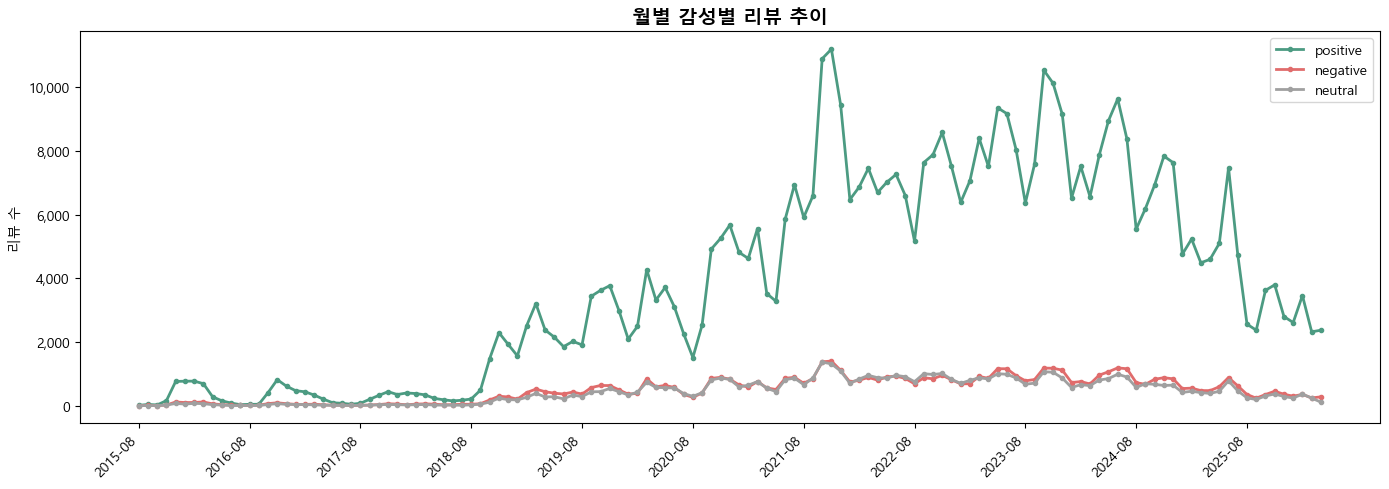

In [47]:
# ── 5-5. 월별 감성별 리뷰 추이 ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
monthly_sent = df.groupby(['연월', 'sentiment']).size().unstack(fill_value=0).sort_index()
for col in ['positive', 'negative', 'neutral']:
    if col in monthly_sent.columns:
        ax.plot(monthly_sent.index, monthly_sent[col],
                label=col, color=COLORS.get(col), linewidth=2, marker='o', markersize=3)
step2 = max(1, len(monthly_sent) // 10)
ax.set_xticks(monthly_sent.index[::step2])
ax.set_xticklabels(monthly_sent.index[::step2], rotation=45, ha='right')
ax.set_title('월별 감성별 리뷰 추이', fontsize=14, fontweight='bold')
ax.set_ylabel('리뷰 수')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

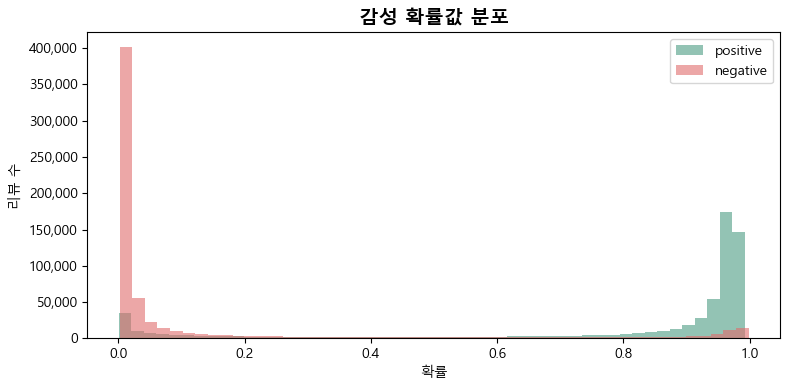

In [48]:
# ── 5-6. 감성 확률값 분포 ───────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for col, label, color in [('p_pos', 'positive', COLORS['positive']),
                           ('p_neg', 'negative', COLORS['negative'])]:
    ax.hist(df[col], bins=50, alpha=0.6, label=label, color=color, edgecolor='none')
ax.set_title('감성 확률값 분포', fontsize=14, fontweight='bold')
ax.set_xlabel('확률')
ax.set_ylabel('리뷰 수')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

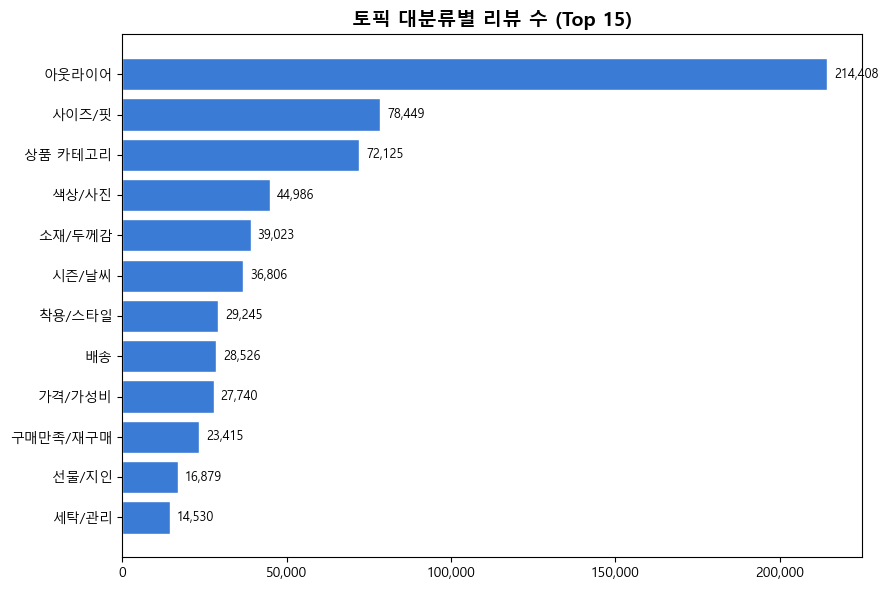

In [49]:
# ── 5-7. 토픽 대분류별 리뷰 수 ─────────────────
fig, ax = plt.subplots(figsize=(9, 6))
cat_cnt = df['topic_category'].value_counts().head(15)
bars7 = ax.barh(cat_cnt.index[::-1], cat_cnt.values[::-1],
                color=COLORS['base'], edgecolor='white')
for b in bars7:
    ax.text(b.get_width() + cat_cnt.max()*0.01,
            b.get_y() + b.get_height()/2,
            f'{int(b.get_width()):,}', va='center', fontsize=9)
ax.set_title('토픽 대분류별 리뷰 수 (Top 15)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

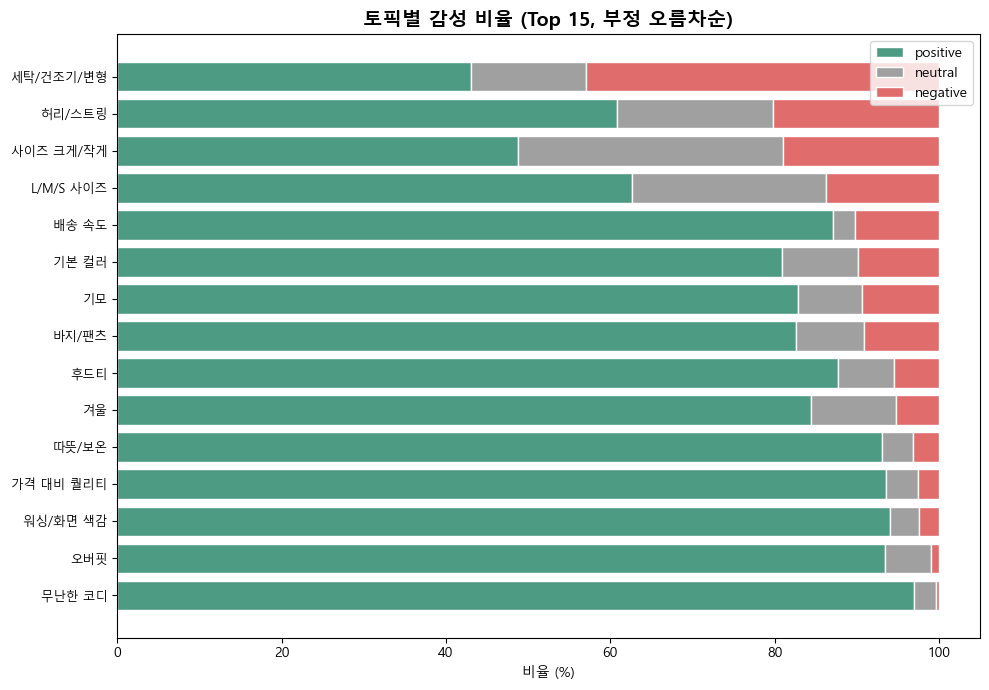

In [50]:
# ── 5-8. 토픽별 감성 비율 (상위 15, 부정 오름차순) ─
fig, ax = plt.subplots(figsize=(10, 7))
top_topics = df[df['topic_name'] != '아웃라이어']['topic_name'].value_counts().head(15).index
df_top = df[df['topic_name'].isin(top_topics)]
topic_sent = pd.crosstab(df_top['topic_name'], df_top['sentiment'], normalize='index') * 100
topic_sent = topic_sent.reindex(columns=['positive', 'neutral', 'negative'])
topic_sent = topic_sent.sort_values('negative', ascending=True)
bottom = np.zeros(len(topic_sent))
for col in ['positive', 'neutral', 'negative']:
    if col in topic_sent.columns:
        ax.barh(topic_sent.index, topic_sent[col],
                left=bottom, label=col,
                color=COLORS.get(col, '#ccc'), edgecolor='white')
        bottom += topic_sent[col].fillna(0).values
ax.set_title('토픽별 감성 비율 (Top 15, 부정 오름차순)', fontsize=14, fontweight='bold')
ax.set_xlabel('비율 (%)')
ax.legend(fontsize=10)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

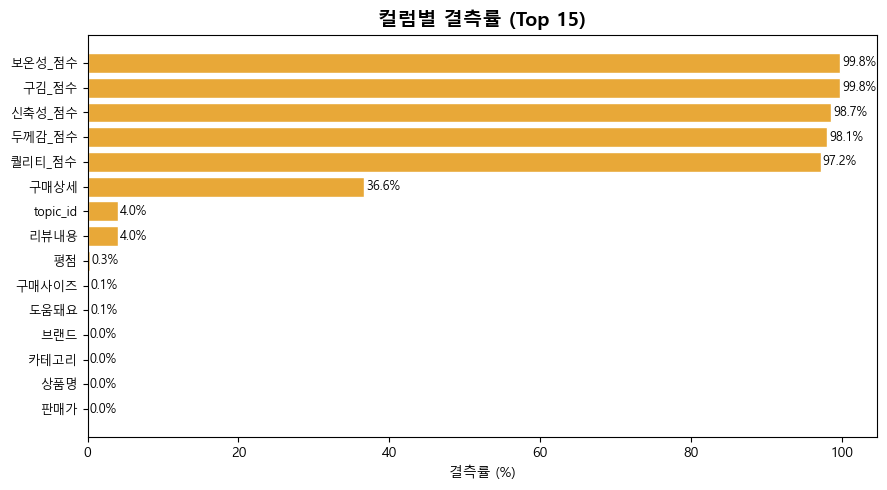

In [51]:
# ── 5-9. 결측치 시각화 ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
if len(missing_df) > 0:
    miss_top = missing_df.head(15)
    bars9 = ax.barh(miss_top.index[::-1], miss_top['결측률(%)'][::-1],
                    color=COLORS['warn'], edgecolor='white')
    for b in bars9:
        ax.text(b.get_width() + 0.3,
                b.get_y() + b.get_height()/2,
                f'{b.get_width():.1f}%', va='center', fontsize=9)
    ax.set_title('컬럼별 결측률 (Top 15)', fontsize=14, fontweight='bold')
    ax.set_xlabel('결측률 (%)')
    ax.tick_params(axis='y', labelsize=9)
else:
    ax.text(0.5, 0.5, '결측치 없음 ✓', ha='center', va='center',
            fontsize=16, color='green', transform=ax.transAxes)
    ax.axis('off')
    ax.set_title('컬럼별 결측률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

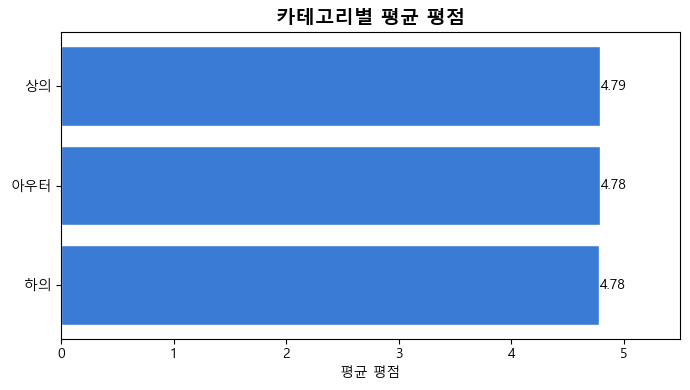

In [52]:
# ── 5-10. 카테고리별 평균 평점 ──────────────────
fig, ax = plt.subplots(figsize=(7, 4))
cat_rating = df.groupby('카테고리')['평점'].mean().sort_values(ascending=True)
bars10 = ax.barh(cat_rating.index, cat_rating.values,
                 color=COLORS['base'], edgecolor='white')
for b in bars10:
    ax.text(b.get_width() + 0.01,
            b.get_y() + b.get_height()/2,
            f'{b.get_width():.2f}', va='center', fontsize=10)
ax.set_xlim(0, 5.5)
ax.set_title('카테고리별 평균 평점', fontsize=14, fontweight='bold')
ax.set_xlabel('평균 평점')
plt.tight_layout()
plt.show()

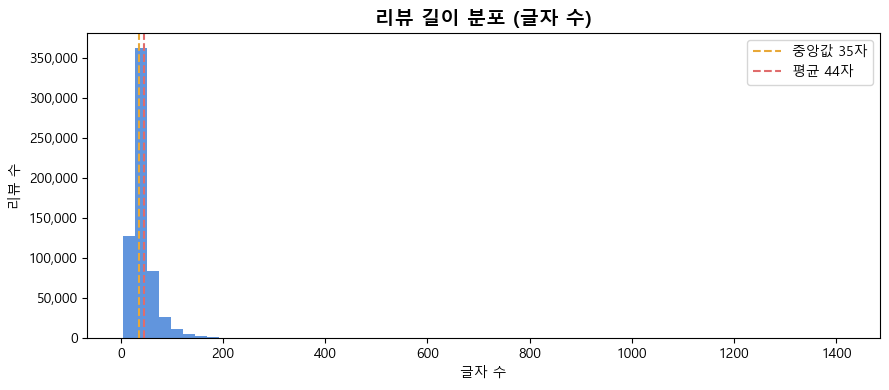

In [53]:
# ── 5-11. 리뷰 길이 분포 ────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
review_len = df['리뷰길이'].dropna()
ax.hist(review_len, bins=60, color=COLORS['base'], edgecolor='none', alpha=0.8)
ax.axvline(review_len.median(), color=COLORS['warn'], linestyle='--',
           linewidth=1.5, label=f'중앙값 {review_len.median():.0f}자')
ax.axvline(review_len.mean(), color=COLORS['negative'], linestyle='--',
           linewidth=1.5, label=f'평균 {review_len.mean():.0f}자')
ax.set_title('리뷰 길이 분포 (글자 수)', fontsize=14, fontweight='bold')
ax.set_xlabel('글자 수')
ax.set_ylabel('리뷰 수')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

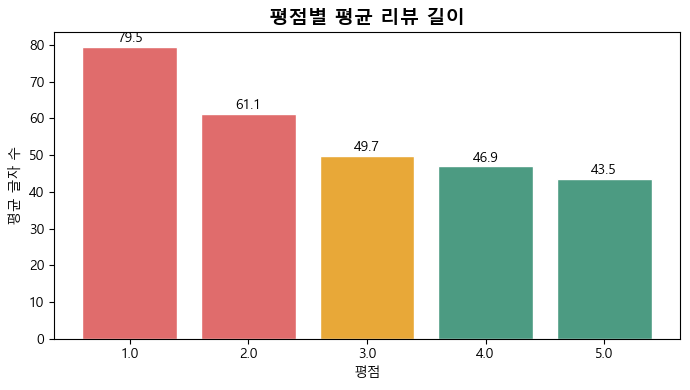

In [54]:
# ── 5-12. 평점별 평균 리뷰 길이 ─────────────────
fig, ax = plt.subplots(figsize=(7, 4))
rating_len = df.groupby('평점')['리뷰길이'].mean()
bar_colors = [COLORS['negative'] if r <= 2 else
              COLORS['warn'] if r == 3 else
              COLORS['positive'] for r in rating_len.index]
bars12 = ax.bar(rating_len.index.astype(str), rating_len.values,
                color=bar_colors, edgecolor='white')
for b in bars12:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=10)
ax.set_title('평점별 평균 리뷰 길이', fontsize=14, fontweight='bold')
ax.set_xlabel('평점')
ax.set_ylabel('평균 글자 수')
plt.tight_layout()
plt.show()

---
## 6. 요약 리포트

In [55]:
issues = []

if dup_cnt > 0:
    issues.append(f'⚠️  중복 리뷰번호 {dup_cnt:,}건')
if nat_cnt > 0:
    issues.append(f'⚠️  작성일 파싱 실패 {nat_cnt:,}건')
if len(invalid_rating) > 0:
    issues.append(f'⚠️  이상 평점값 존재: {invalid_rating}')
if len(weird) > 0:
    issues.append(f'⚠️  확률 합 이상 {len(weird)}건')

outlier_pct = len(outlier) / len(df) * 100
if outlier_pct > 20:
    issues.append(f'⚠️  토픽 아웃라이어 비율 높음: {outlier_pct:.1f}%')

ambig_pct = (max_prob < 0.7).mean() * 100
if ambig_pct > 10:
    issues.append(f'⚠️  감성 신뢰도 0.7 미만 {ambig_pct:.1f}% — 검토 필요')

contradiction_pct = (len(high_neg) + len(low_pos)) / len(df) * 100
if contradiction_pct > 5:
    issues.append(f'⚠️  평점-감성 모순 케이스 {contradiction_pct:.1f}%')

print('=' * 55)
print('전처리 품질 요약')
print('=' * 55)
print(f'총 리뷰   : {len(df):,}건')
print(f'기간      : {df["작성일"].min().date()} ~ {df["작성일"].max().date()}')
print(f'브랜드    : {df["브랜드"].unique().tolist()}')
print(f'카테고리  : {df["카테고리"].unique().tolist()}')
print(f'토픽 수   : {df[df["topic_id"] != -1]["topic_id"].nunique()}개 (아웃라이어 제외)')
print()
if issues:
    print('발견된 이슈:')
    for i in issues:
        print(f'  {i}')
else:
    print('✅ 주요 이슈 없음')

전처리 품질 요약
총 리뷰   : 626,132건
기간      : 2015-08-13 ~ 2026-04-29
브랜드    : ['제멋', '트래블', '필루미네이트', nan]
카테고리  : ['상의', '하의', '아우터', nan]
토픽 수   : 68개 (아웃라이어 제외)

발견된 이슈:
  ⚠️  중복 리뷰번호 419건
  ⚠️  이상 평점값 존재: [nan]
  ⚠️  토픽 아웃라이어 비율 높음: 30.2%
  ⚠️  감성 신뢰도 0.7 미만 12.3% — 검토 필요
  ⚠️  평점-감성 모순 케이스 8.2%
